In [3]:
#開始

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_1827/3758615875.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  EXC = yf.download("PGR", start = "2020-06-20",end ="2025-06-20")[['Close']]
[*********************100%***********************]  1 of 1 completed


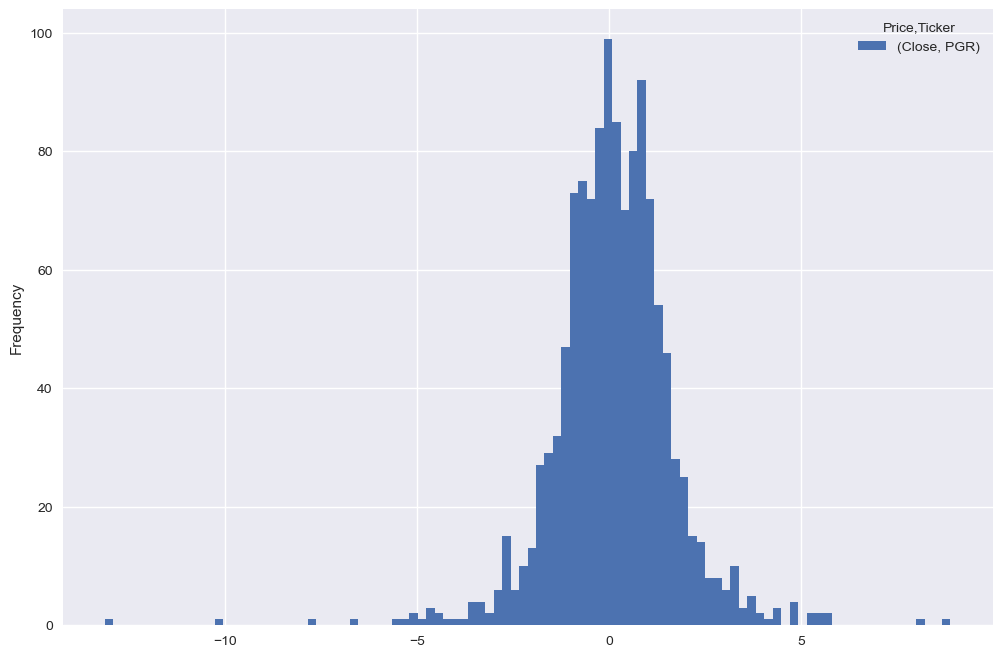

In [5]:
#統計單隻股票每日升跌百分比並畫圖
EXC = yf.download("PGR", start = "2020-06-20",end ="2025-06-20")[['Close']]
ret=EXC.pct_change().mul(100).dropna()
plt.style.use("seaborn-v0_8")
ret.plot(kind="hist",figsize=(12,8),bins=100)
plt.show()

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_1827/3101394677.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  PLTR = yf.download("PLTR")
[*********************100%***********************]  1 of 1 completed
/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_1827/3101394677.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pltr["SMA50"] = pltr.PLTR.rolling(window=50, min_periods=50).mean()
/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_1827/3101394677.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

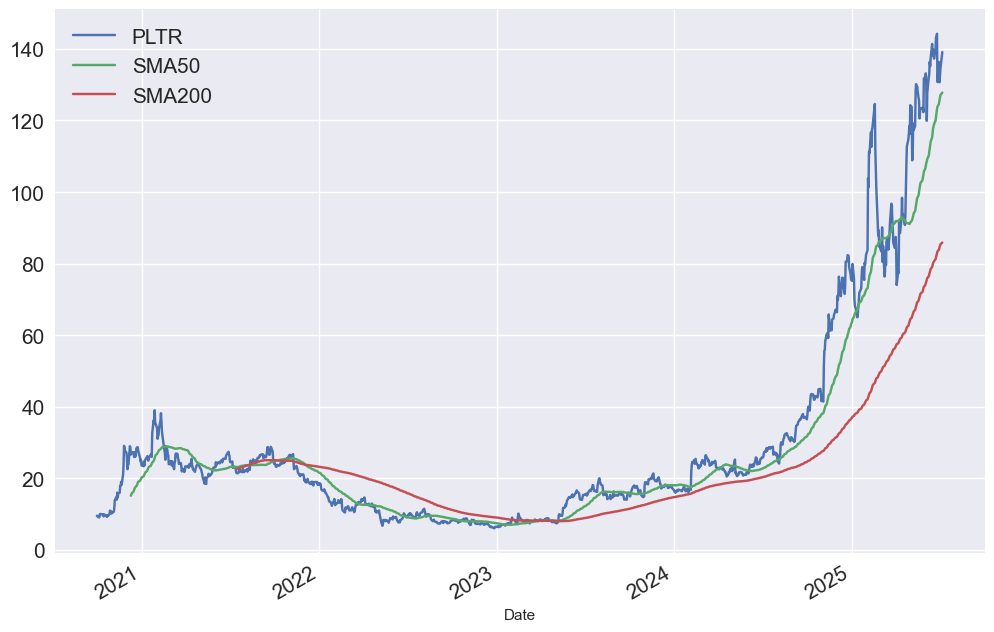

In [6]:
#幫股票畫MA線
PLTR = yf.download("PLTR")
pltr = PLTR.Close
pltr["SMA50"] = pltr.PLTR.rolling(window=50, min_periods=50).mean()
pltr["SMA200"] = pltr.PLTR.rolling(window=200, min_periods=200).mean()
plt.style.use("seaborn-v0_8")
pltr.plot(figsize=(12,8),fontsize=15)
plt.legend(loc="upper left",fontsize=15)
plt.show()

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_1827/4101827535.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download(ticker, start = "2010-01-01",end ="2021-01-01")
[*********************100%***********************]  6 of 6 completed


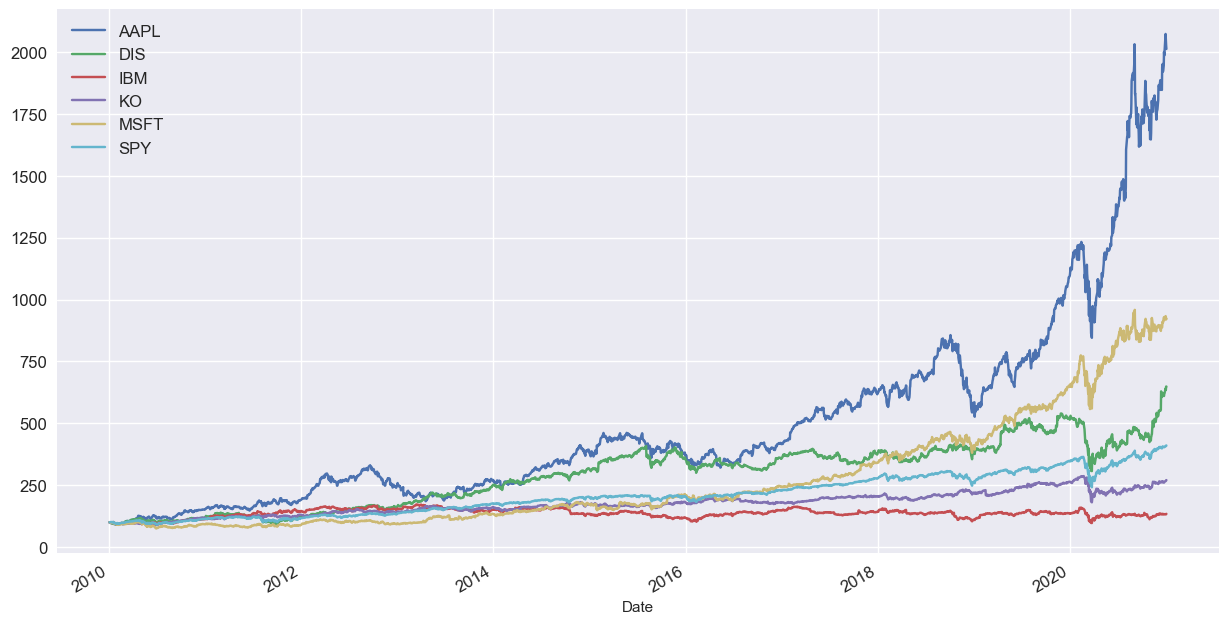

In [7]:
#比較多個單隻股票升勢
ticker=["SPY","AAPL","KO","IBM","DIS","MSFT"]
stocks = yf.download(ticker, start = "2010-01-01",end ="2021-01-01")
close=stocks.loc[:,"Close"].copy()
normclose=close.div(close.iloc[0]).mul(100)
plt.style.use("seaborn-v0_8")
normclose.plot(figsize=(15,8),fontsize=12)
plt.legend(fontsize=12)
plt.show()

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_1827/3208165726.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download(ticker, start = "2015-07-08",end ="2025-07-08")
[*********************100%***********************]  6 of 6 completed


Text(0.5, 1.0, 'Risk/return')

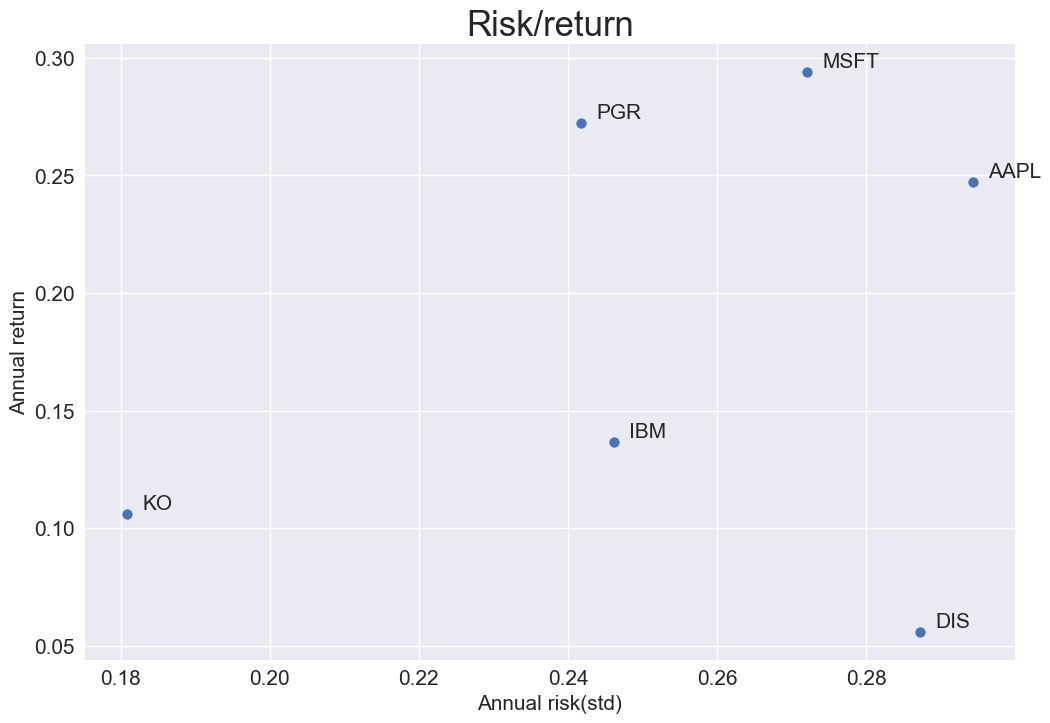

In [11]:
#比較多個單隻股票回報及風險比
ticker=["PGR","AAPL","KO","IBM","DIS","MSFT"]
stocks = yf.download(ticker, start = "2015-07-08",end ="2025-07-08")
close=stocks.loc[:,"Close"].copy()
ret=close.pct_change().dropna()
summary=ret.describe().T.loc[:,["mean","std"]]
summary["mean"]=summary["mean"]*252
summary["std"]=summary["std"]*np.sqrt(252)
summary.plot.scatter(x="std",y="mean",figsize=(12,8),s=50,fontsize=15)
for i in summary.index:
    plt.annotate(i,xy=(summary.loc[i,"std"]+0.002,summary.loc[i,"mean"]+0.002),size=15)
plt.xlabel("Annual risk(std)",fontsize=15)
plt.ylabel("Annual return",fontsize=15)
plt.title("Risk/return",fontsize=25)

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_81946/3543120169.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stocks = yf.download(ticker, start = "2010-01-01",end ="2021-01-01")
[*********************100%***********************]  6 of 6 completed


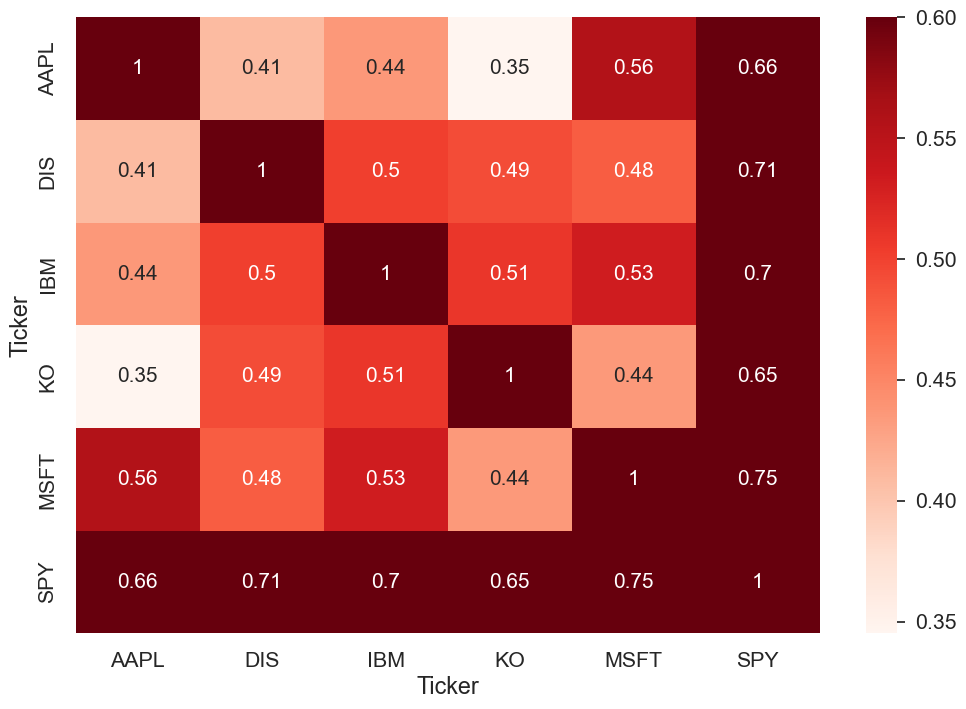

In [59]:
#比較股票與股票之間Correlation
ticker=["SPY","AAPL","KO","IBM","DIS","MSFT"]
stocks = yf.download(ticker, start = "2010-01-01",end ="2021-01-01")
close=stocks.loc[:,"Close"].copy()
ret=close.pct_change().dropna()
plt.figure(figsize=(12,8))
sns.set(font_scale=1.4)
sns.heatmap(ret.corr(),cmap="Reds",annot=True,annot_kws={"size":15},vmax=0.6)
plt.show()

In [60]:
class StockAnalyzer:
    def __init__(self, tickers, start_date="2010-01-01", end_date="2021-01-01"):
        self.tickers = tickers
        self.start_date = start_date
        self.end_date = end_date
        self.stocks = yf.download(tickers, start=start_date, end=end_date)
        self.close = self.stocks.loc[:, "Close"].copy()
    
    def plot_normalized_prices(self):
        normclose = self.close.div(self.close.iloc[0]).mul(100)
        plt.style.use("seaborn-v0_8")
        normclose.plot(figsize=(15, 8), fontsize=12)
        plt.legend(fontsize=12)
        plt.show()
    
    def plot_risk_return(self):
        ret = self.close.pct_change().dropna()
        summary = ret.describe().T.loc[:, ["mean", "std"]]
        summary["mean"] = summary["mean"] * 252
        summary["std"] = summary["std"] * np.sqrt(252)
        
        summary.plot.scatter(x="std", y="mean", figsize=(12, 8), s=50, fontsize=15)
        for i in summary.index:
            plt.annotate(i, xy=(summary.loc[i, "std"] + 0.002, summary.loc[i, "mean"] + 0.002), size=15)
        plt.xlabel("Annual risk (std)", fontsize=15)
        plt.ylabel("Annual return", fontsize=15)
        plt.title("Risk/return", fontsize=25)
        plt.show()
    
    def plot_correlation_heatmap(self):
        ret = self.close.pct_change().dropna()
        plt.figure(figsize=(12, 8))
        sns.set(font_scale=1.4)
        sns.heatmap(ret.corr(), cmap="Reds", annot=True, annot_kws={"size": 15}, vmax=0.6)
        plt.show()

In [61]:
tickers = ["SPY", "AAPL", "KO", "IBM", "DIS", "MSFT"]

In [62]:
analyzer = StockAnalyzer(tickers)

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_81946/3433243168.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  self.stocks = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  6 of 6 completed


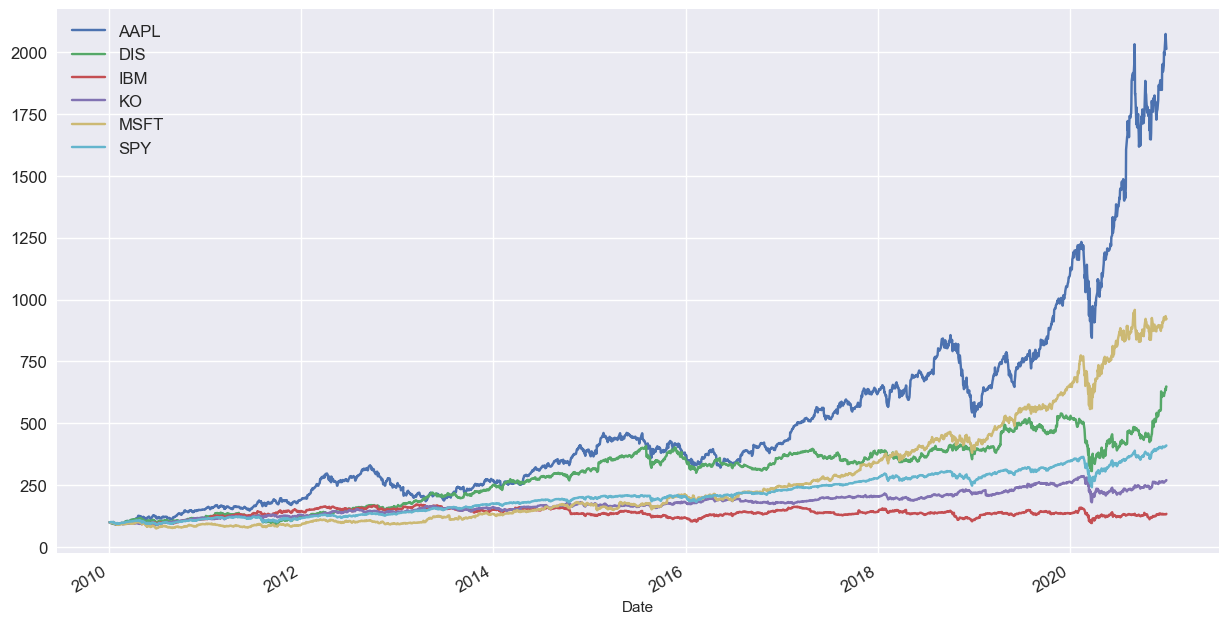

In [63]:
analyzer.plot_normalized_prices()

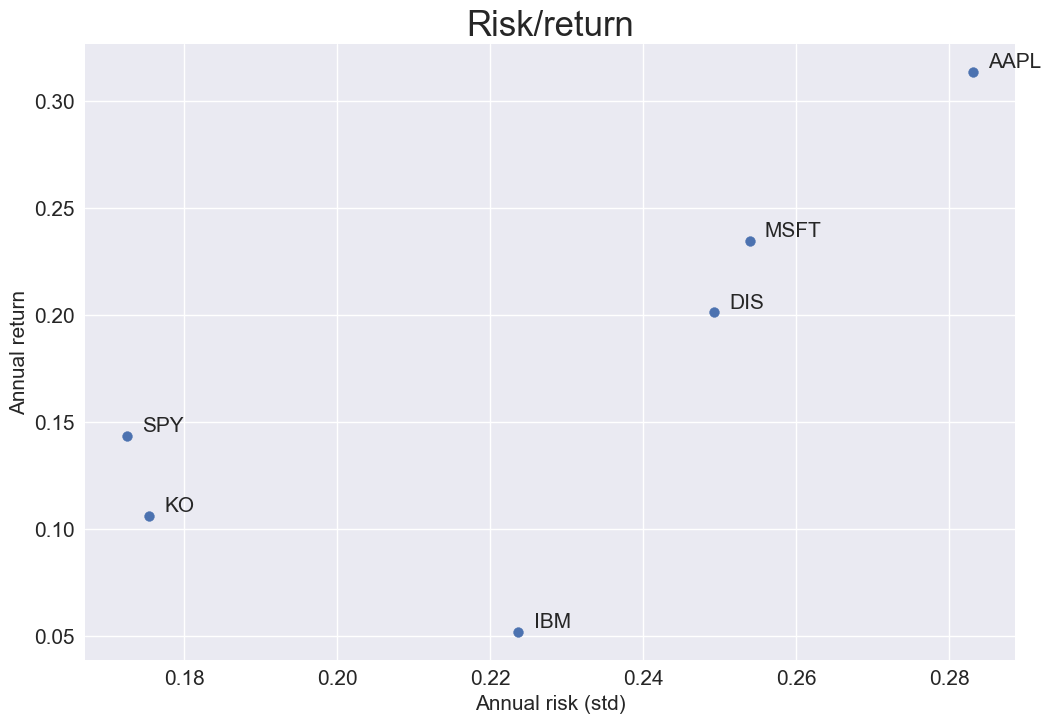

In [64]:
analyzer.plot_risk_return()

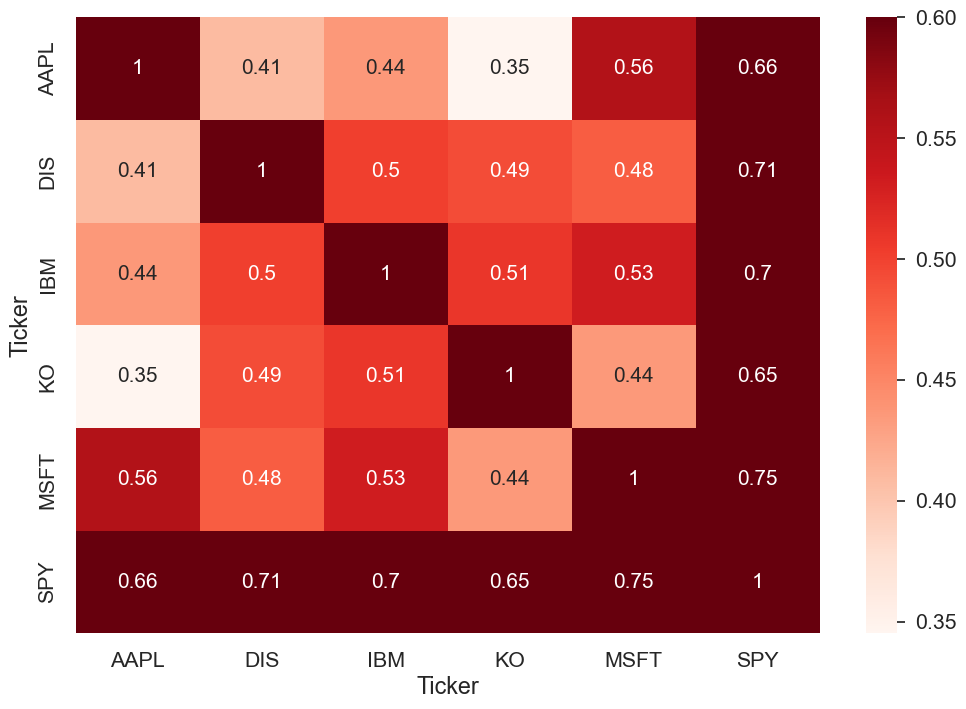

In [65]:
analyzer.plot_correlation_heatmap()

In [5]:
class SMABacktester:
    def __init__(self, symbol, SMA_S, SMA_L, start, end):
        self.symbol = symbol
        self.SMA_S = SMA_S
        self.SMA_L = SMA_L
        self.start = start
        self.end = end
        self.results = None
        self.get_data()
        
    def get_data(self):
        df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
        data = df
        data["returns"] = np.log(data.Close.div(data.Close.shift(1)))
        data["SMA_S"] = data.Close.rolling(self.SMA_S).mean()
        data["SMA_L"] = data.Close.rolling(self.SMA_L).mean()
        data.dropna(inplace=True)
        self.data2 = data
        return data
    
    def test_results(self):
        data = self.data2.copy().dropna()
        data["position"] = np.where(data["SMA_S"] > data["SMA_L"], 1, -1)
        data["strategy"] = data["returns"] * data.position.shift(1)
        data.dropna(inplace=True)
        data["returnsbh"] = data["returns"].cumsum().apply(np.exp)
        data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)
        perf = data["returnsstrategy"].iloc[-1]
        outperf = perf - data["returnsbh"].iloc[-1]
        self.results = data
        ret = np.exp(data["strategy"].sum())
        std = data["strategy"].std() * np.sqrt(252)
        return round(perf, 6), round(outperf, 6)
    
    def plot_results(self):
        if self.results is None:
            print("Run the test please")
        else:
            title = "{} | SMA_S={} | SMA_L={}".format(self.symbol, self.SMA_S, self.SMA_L)
            self.results[["returnsbh", "returnsstrategy"]].plot(title=title, figsize=(12, 8))
            plt.show()
    
    def plot_moving_averages(self):
        data = self.data2.copy()
        plt.style.use("seaborn-v0_8")
        data[["Close", "SMA_S", "SMA_L"]].plot(figsize=(12, 8), fontsize=15)
        plt.legend(loc="upper left", fontsize=15)
        plt.title(f"{self.symbol} Price with SMA{self.SMA_S} and SMA{self.SMA_L}", fontsize=15)
        plt.show()
    
    def plot_return_histogram(self):
        data = self.data2.copy()
        ret = data["Close"].pct_change().mul(100).dropna()
        plt.style.use("seaborn-v0_8")
        ret.plot(kind="hist", figsize=(12, 8), bins=100)
        plt.title(f"{self.symbol} Daily Return Distribution", fontsize=15)
        plt.xlabel("Daily Return (%)", fontsize=15)
        plt.ylabel("Frequency", fontsize=15)
        plt.show()

In [6]:
backtester = SMABacktester("PGR", 50, 200, "2020-06-20", "2025-06-20")

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_87997/147228358.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
[*********************100%***********************]  1 of 1 completed


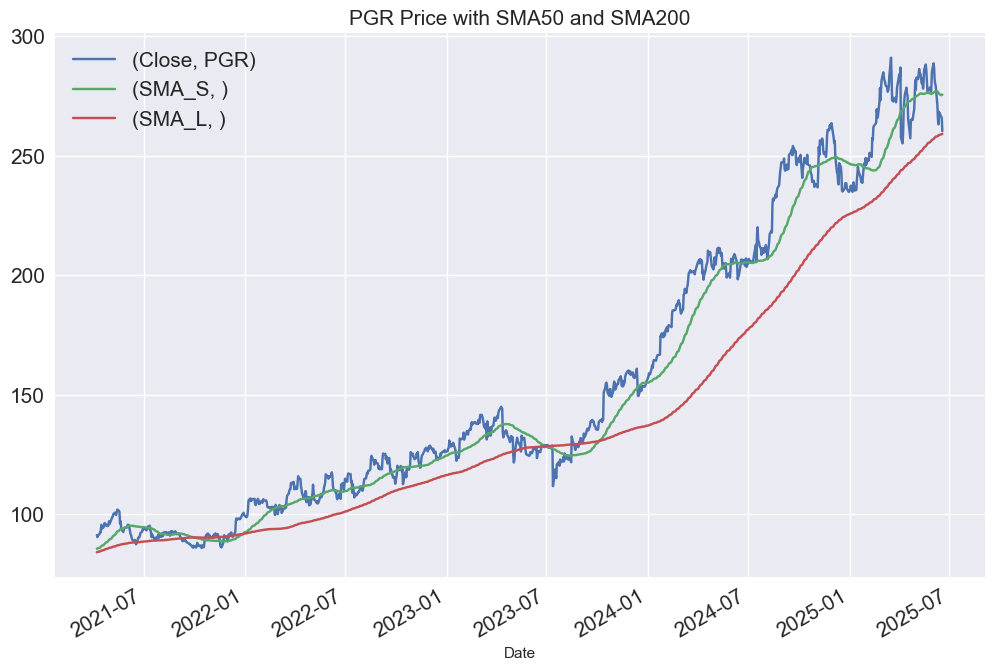

In [7]:
backtester.plot_moving_averages()

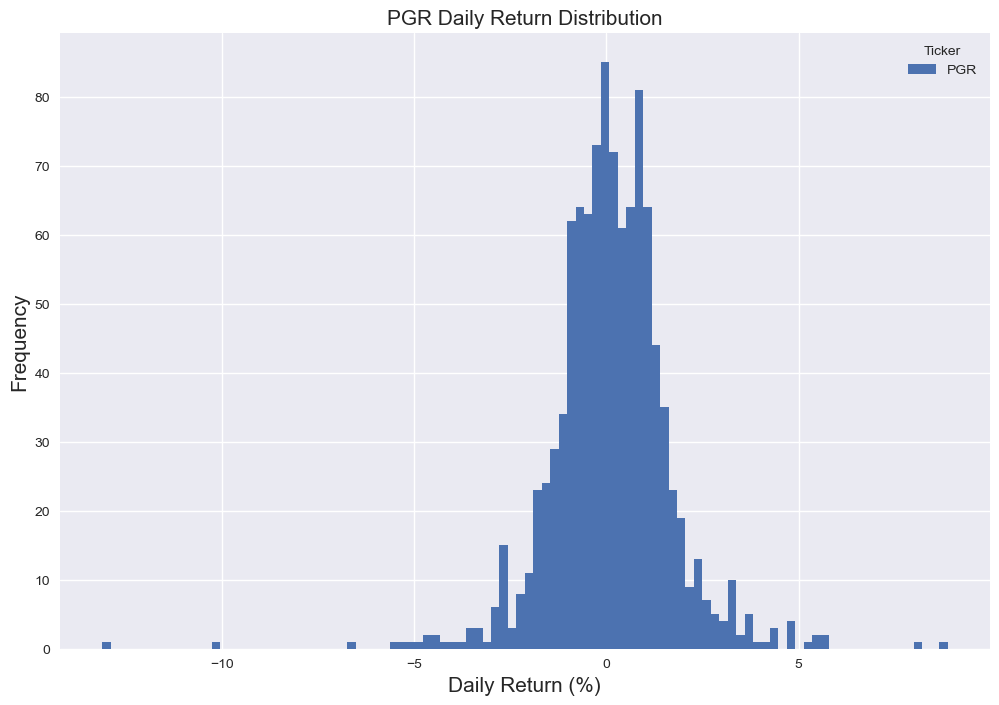

In [8]:
backtester.plot_return_histogram()